In [3]:
!pip install datasets soundfile espeak-ng phonemizer dvc transformers torchaudio jiwer

ERROR: Could not find a version that satisfies the requirement espeak-ng (from versions: none)
ERROR: No matching distribution found for espeak-ng


In [4]:
!apt-get install -y espeak-ng

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  espeak-ng-data libespeak-ng1 libpcaudio0 libsonic0
The following NEW packages will be installed:
  espeak-ng espeak-ng-data libespeak-ng1 libpcaudio0 libsonic0
0 upgraded, 5 newly installed, 0 to remove and 37 not upgraded.
Need to get 4,526 kB of archives.
After this operation, 11.9 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libpcaudio0 amd64 1.1-6build2 [8,956 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libsonic0 amd64 0.2.0-11build1 [10.3 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 espeak-ng-data amd64 1.50+dfsg-10ubuntu0.1 [3,956 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libespeak-ng1 amd64 1.50+dfsg-10ubuntu0.1 [207 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 espeak-ng amd64 1.50+dfsg-1

In [5]:
!pip install phonemizer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 41.0 MB/s eta 0:00:00


In [6]:
!pip install datasets soundfile transformers torchaudio jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.6 MB/s eta 0:00:00


In [7]:
import datasets
import soundfile as sf
import transformers
import torchaudio
import jiwer
from phonemizer import phonemize

print("All imports successful!")

All imports successful!


In [8]:
import itertools
from datasets import load_dataset

# Load a small sample of LibriSpeech English
dataset = load_dataset("librispeech_asr", "clean", split="test", streaming=True, trust_remote_code=True)

# Take just 20 utterances
samples = list(itertools.islice(dataset, 20))

print(f"Loaded {len(samples)} samples")
print("Example sample keys:", samples[0].keys())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'librispeech_asr' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'librispeech_asr' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse th

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Loaded 20 samples
Example sample keys: dict_keys(['file', 'audio', 'text', 'speaker_id', 'chapter_id', 'id'])


In [9]:
import os
import json
import hashlib
import soundfile as sf

# Create directories
os.makedirs("data/raw/en/wav", exist_ok=True)
os.makedirs("data/manifests/en", exist_ok=True)

manifest_entries = []

for sample in samples:
    # Save audio file
    utt_id = f"en_{sample['id']}"
    wav_path = f"data/raw/en/wav/{sample['id']}.wav"

    audio_array = sample['audio']['array']
    sr = sample['audio']['sampling_rate']

    sf.write(wav_path, audio_array, sr)

    # Compute md5
    with open(wav_path, 'rb') as f:
        audio_md5 = hashlib.md5(f.read()).hexdigest()

    entry = {
        "utt_id": utt_id,
        "lang": "en",
        "wav_path": wav_path,
        "ref_text": sample['text'],
        "ref_phon": None,  # will fill in next step
        "sr": sr,
        "duration_s": round(len(audio_array) / sr, 2),
        "audio_md5": audio_md5,
        "snr_db": None
    }

    manifest_entries.append(entry)

print(f"Saved {len(manifest_entries)} audio files")
print("Example entry:", manifest_entries[0])

Saved 20 audio files
Example entry: {'utt_id': 'en_6930-75918-0000', 'lang': 'en', 'wav_path': 'data/raw/en/wav/6930-75918-0000.wav', 'ref_text': 'CONCORD RETURNED TO ITS PLACE AMIDST THE TENTS', 'ref_phon': None, 'sr': 16000, 'duration_s': 3.5, 'audio_md5': 'd6fdbcc46eb533990b07c22979069c50', 'snr_db': None}


In [10]:
from phonemizer import phonemize

for entry in manifest_entries:
    entry['ref_phon'] = phonemize(
        entry['ref_text'],
        backend='espeak',
        language='en-us',
        with_stress=True
    )

print("Example phoneme output:")
print(f"Text: {manifest_entries[0]['ref_text']}")
print(f"Phonemes: {manifest_entries[0]['ref_phon']}")

Example phoneme output:
Text: CONCORD RETURNED TO ITS PLACE AMIDST THE TENTS
Phonemes: kəŋkˈoːɹd ɹᵻtˈɜːnd tuː ɪts plˈeɪs ɐmˈɪdst ðə tˈɛnts 


In [11]:
import tempfile
import os

manifest_path = "data/manifests/en/clean.jsonl"
tmp_path = manifest_path + ".tmp"

with open(tmp_path, 'w', encoding='utf-8') as f:
    for entry in manifest_entries:
        f.write(json.dumps(entry) + '\n')

# Atomic rename
os.replace(tmp_path, manifest_path)

print(f"Manifest written to {manifest_path}")

# Verify it
with open(manifest_path, 'r') as f:
    lines = f.readlines()
print(f"Manifest contains {len(lines)} entries")

Manifest written to data/manifests/en/clean.jsonl
Manifest contains 20 entries


In [12]:
import numpy as np
import soundfile as sf

def add_noise(signal, snr_db, rng):
    signal_power = np.mean(signal ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = rng.normal(loc=0.0, scale=np.sqrt(noise_power), size=signal.shape)
    return signal + noise

def add_noise_to_file(input_wav, output_wav, snr_db, seed=None):
    signal, sr = sf.read(input_wav)
    if signal.ndim != 1:
        raise ValueError("Only mono audio is supported")
    rng = np.random.default_rng(seed)
    noisy_signal = add_noise(signal, snr_db, rng)
    sf.write(output_wav, noisy_signal, sr)

print("Noise functions defined successfully!")

Noise functions defined successfully!


In [13]:
# Define SNR levels (higher = less noise, lower = more noise)
snr_levels = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]

noisy_manifests = {}  # will store one manifest per SNR level

for snr in snr_levels:
    os.makedirs(f"data/raw/en/wav_snr{snr}", exist_ok=True)
    os.makedirs(f"data/manifests/en", exist_ok=True)

    noisy_entries = []

    for entry in manifest_entries:
        # Create noisy wav path
        filename = os.path.basename(entry['wav_path'])
        noisy_wav_path = f"data/raw/en/wav_snr{snr}/{filename}"

        # Add noise
        add_noise_to_file(
            input_wav=entry['wav_path'],
            output_wav=noisy_wav_path,
            snr_db=snr,
            seed=42  # fixed seed for reproducibility
        )

        # Compute md5 of noisy file
        with open(noisy_wav_path, 'rb') as f:
            noisy_md5 = hashlib.md5(f.read()).hexdigest()

        noisy_entry = entry.copy()
        noisy_entry['wav_path'] = noisy_wav_path
        noisy_entry['snr_db'] = snr
        noisy_entry['audio_md5'] = noisy_md5

        noisy_entries.append(noisy_entry)

    # Write manifest atomically
    manifest_path = f"data/manifests/en/noisy_snr{snr}.jsonl"
    tmp_path = manifest_path + ".tmp"

    with open(tmp_path, 'w', encoding='utf-8') as f:
        for e in noisy_entries:
            f.write(json.dumps(e) + '\n')

    os.replace(tmp_path, manifest_path)
    noisy_manifests[snr] = noisy_entries
    print(f"SNR {snr}dB manifest written with {len(noisy_entries)} entries")

print("All noisy manifests created!")

SNR 0dB manifest written with 20 entries
SNR 5dB manifest written with 20 entries
SNR 10dB manifest written with 20 entries
SNR 15dB manifest written with 20 entries
SNR 20dB manifest written with 20 entries
SNR 25dB manifest written with 20 entries
SNR 30dB manifest written with 20 entries
SNR 35dB manifest written with 20 entries
SNR 40dB manifest written with 20 entries
SNR 45dB manifest written with 20 entries
All noisy manifests created!


In [14]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import torch

print("Loading model...")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-lv-60-espeak-cv-ft")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-lv-60-espeak-cv-ft")
model.eval()

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model loaded! Running on: {device}")

Loading model...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Model loaded! Running on: cuda


In [15]:
import torch

def predict_phonemes(wav_path, processor, model, device):
    signal, sr = sf.read(wav_path)

    # Process audio
    inputs = processor(
        signal,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        logits = model(input_values).logits

    # Decode prediction
    predicted_ids = torch.argmax(logits, dim=-1)
    predicted_phonemes = processor.batch_decode(predicted_ids)

    return predicted_phonemes[0]

# Test on one file first
test_prediction = predict_phonemes(
    manifest_entries[0]['wav_path'],
    processor, model, device
)

print(f"Reference phonemes: {manifest_entries[0]['ref_phon']}")
print(f"Predicted phonemes: {test_prediction}")

Reference phonemes: kəŋkˈoːɹd ɹᵻtˈɜːnd tuː ɪts plˈeɪs ɐmˈɪdst ðə tˈɛnts 
Predicted phonemes: k ɑː n k ɔːɹ d ɹ ᵻ t ɜː n d t uː ɪ t s p l eɪ s ɐ m ɪ t s ð ə t ɛ n t s


In [16]:
def normalise_phonemes(phoneme_str):
    # Remove stress markers and extra whitespace, lowercase
    phoneme_str = phoneme_str.replace("ˈ", "").replace("ˌ", "")
    # Split into individual characters and rejoin with spaces
    tokens = list(phoneme_str.replace(" ", ""))
    return " ".join(tokens)

# Test normalisation
ref_norm = normalise_phonemes(manifest_entries[0]['ref_phon'])
pred_norm = normalise_phonemes(test_prediction)

print(f"Normalised reference: {ref_norm}")
print(f"Normalised prediction: {pred_norm}")

Normalised reference: k ə ŋ k o ː ɹ d ɹ ᵻ t ɜ ː n d t u ː ɪ t s p l e ɪ s ɐ m ɪ d s t ð ə t ɛ n t s
Normalised prediction: k ɑ ː n k ɔ ː ɹ d ɹ ᵻ t ɜ ː n d t u ː ɪ t s p l e ɪ s ɐ m ɪ t s ð ə t ɛ n t s


In [17]:
from jiwer import wer

def calculate_per(reference, hypothesis):
    # PER is identical to WER when each phoneme is a single token
    return wer(reference, hypothesis)

# Run predictions on all SNR levels
results = {}  # snr -> average PER

for snr in snr_levels:
    print(f"Running inference for SNR {snr}dB...")
    per_scores = []

    for entry in noisy_manifests[snr]:
        # Get prediction
        pred = predict_phonemes(entry['wav_path'], processor, model, device)

        # Normalise both
        ref_norm = normalise_phonemes(entry['ref_phon'])
        pred_norm = normalise_phonemes(pred)

        # Calculate PER
        per = calculate_per(ref_norm, pred_norm)
        per_scores.append(per)

    avg_per = sum(per_scores) / len(per_scores)
    results[snr] = avg_per
    print(f"SNR {snr}dB -> Average PER: {avg_per:.3f}")

print("\nAll done!")
print(results)

Running inference for SNR 0dB...
SNR 0dB -> Average PER: 0.742
Running inference for SNR 5dB...
SNR 5dB -> Average PER: 0.328
Running inference for SNR 10dB...
SNR 10dB -> Average PER: 0.152
Running inference for SNR 15dB...
SNR 15dB -> Average PER: 0.124
Running inference for SNR 20dB...
SNR 20dB -> Average PER: 0.120
Running inference for SNR 25dB...
SNR 25dB -> Average PER: 0.118
Running inference for SNR 30dB...
SNR 30dB -> Average PER: 0.117
Running inference for SNR 35dB...
SNR 35dB -> Average PER: 0.117
Running inference for SNR 40dB...
SNR 40dB -> Average PER: 0.118
Running inference for SNR 45dB...
SNR 45dB -> Average PER: 0.119

All done!
{0: 0.7417621894698228, 5: 0.3277259602401516, 10: 0.1521020931302462, 15: 0.12413421165609544, 20: 0.12041675586162652, 25: 0.11772457311195057, 30: 0.11729598917121117, 35: 0.11676893230427336, 40: 0.11840932383104216, 45: 0.11888886347298591}


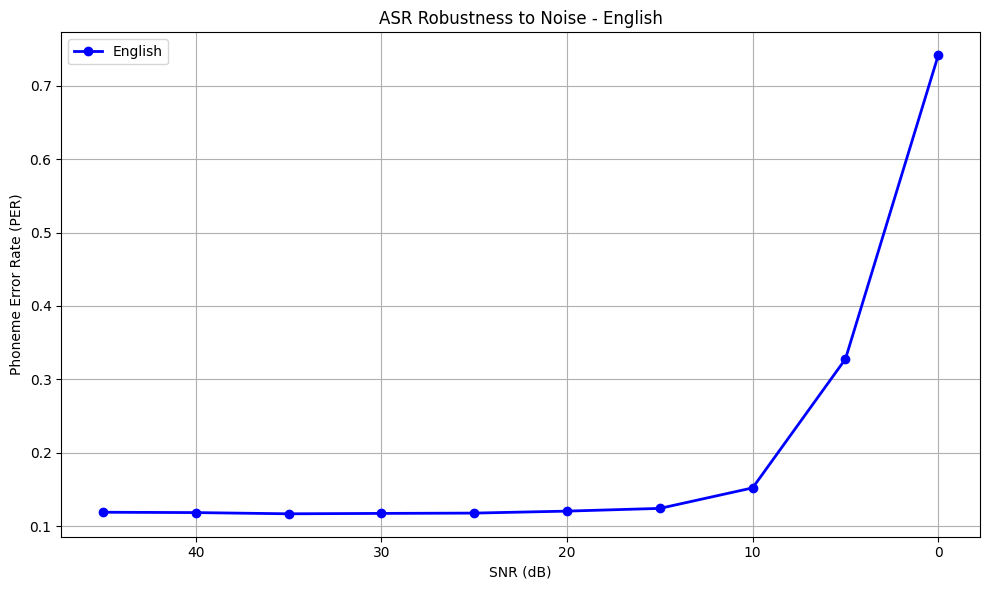

Figure saved!


In [18]:
import matplotlib.pyplot as plt

os.makedirs("outputs/figures", exist_ok=True)

snr_values = list(results.keys())
per_values = list(results.values())

plt.figure(figsize=(10, 6))
plt.plot(snr_values, per_values, marker='o', linewidth=2, color='blue', label='English')
plt.xlabel('SNR (dB)')
plt.ylabel('Phoneme Error Rate (PER)')
plt.title('ASR Robustness to Noise - English')
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()  # more noise on the left
plt.tight_layout()
plt.savefig("outputs/figures/per_vs_snr_en.png", dpi=150)
plt.show()

print("Figure saved!")

In [19]:
import json

os.makedirs("outputs/metrics", exist_ok=True)

metrics = {
    "english": {
        f"snr_{snr}db": round(per, 4)
        for snr, per in results.items()
    }
}

metrics_path = "outputs/metrics/per_results.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved!")
print(json.dumps(metrics, indent=2))

Metrics saved!
{
  "english": {
    "snr_0db": 0.7418,
    "snr_5db": 0.3277,
    "snr_10db": 0.1521,
    "snr_15db": 0.1241,
    "snr_20db": 0.1204,
    "snr_25db": 0.1177,
    "snr_30db": 0.1173,
    "snr_35db": 0.1168,
    "snr_40db": 0.1184,
    "snr_45db": 0.1189
  }
}


In [20]:
import json

os.makedirs("outputs/metrics", exist_ok=True)

metrics = {
    "english": {
        f"snr_{snr}db": round(per, 4)
        for snr, per in results.items()
    }
}

metrics_path = "outputs/metrics/per_results.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved!")
print(json.dumps(metrics, indent=2))

Metrics saved!
{
  "english": {
    "snr_0db": 0.7418,
    "snr_5db": 0.3277,
    "snr_10db": 0.1521,
    "snr_15db": 0.1241,
    "snr_20db": 0.1204,
    "snr_25db": 0.1177,
    "snr_30db": 0.1173,
    "snr_35db": 0.1168,
    "snr_40db": 0.1184,
    "snr_45db": 0.1189
  }
}


In [21]:
# Load French data
dataset_fr = load_dataset("librispeech_asr", "clean", split="test", streaming=True, trust_remote_code=True)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'librispeech_asr' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'librispeech_asr' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

In [23]:
dataset_fr = load_dataset(
    "facebook/voxpopuli",
    "fr",
    split="test",
    streaming=True,
    trust_remote_code=True
)

samples_fr = list(itertools.islice(dataset_fr, 20))

print(f"Loaded {len(samples_fr)} French samples")
print("Keys:", samples_fr[0].keys())

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/voxpopuli' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'facebook/voxpopuli' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded 20 French samples
Keys: dict_keys(['audio_id', 'language', 'audio', 'raw_text', 'normalized_text', 'gender', 'speaker_id', 'is_gold_transcript', 'accent'])


In [24]:
os.makedirs("data/raw/fr/wav", exist_ok=True)
os.makedirs("data/manifests/fr", exist_ok=True)

manifest_entries_fr = []

for sample in samples_fr:
    utt_id = f"fr_{sample['audio_id']}"
    wav_path = f"data/raw/fr/wav/{sample['audio_id']}.wav"

    audio_array = sample['audio']['array']
    sr = sample['audio']['sampling_rate']

    # Resample to 16000 if needed
    if sr != 16000:
        import torchaudio
        waveform = torch.tensor(audio_array).unsqueeze(0)
        resampler = torchaudio.transforms.Resample(sr, 16000)
        audio_array = resampler(waveform).squeeze(0).numpy()
        sr = 16000

    sf.write(wav_path, audio_array, sr)

    with open(wav_path, 'rb') as f:
        audio_md5 = hashlib.md5(f.read()).hexdigest()

    entry = {
        "utt_id": utt_id,
        "lang": "fr",
        "wav_path": wav_path,
        "ref_text": sample['normalized_text'],
        "ref_phon": None,
        "sr": sr,
        "duration_s": round(len(audio_array) / sr, 2),
        "audio_md5": audio_md5,
        "snr_db": None
    }

    manifest_entries_fr.append(entry)

print(f"Saved {len(manifest_entries_fr)} French audio files")
print("Example entry:", manifest_entries_fr[0])

Saved 20 French audio files
Example entry: {'utt_id': 'fr_20131024-0900-PLENARY-4-fr_20131024-10:24:36_6', 'lang': 'fr', 'wav_path': 'data/raw/fr/wav/20131024-0900-PLENARY-4-fr_20131024-10:24:36_6.wav', 'ref_text': 'je souhaite juste rappeler que ces droits de plantation étaient intégrés dans la réforme de deux mille huit qui a été adoptée par le conseil des ministres. mais malgré cela et au delà de cela dans le cadre de cette réforme deux mille treize nous sommes revenus sur cette question compte tenu aussi du rapport', 'ref_phon': None, 'sr': 16000, 'duration_s': 20.1, 'audio_md5': 'c4d92893763d6438c97d67279ec21154', 'snr_db': None}


In [25]:
for entry in manifest_entries_fr:
    entry['ref_phon'] = phonemize(
        entry['ref_text'],
        backend='espeak',
        language='fr-fr',
        with_stress=True
    )

print("Example French phoneme output:")
print(f"Text: {manifest_entries_fr[0]['ref_text'][:50]}...")
print(f"Phonemes: {manifest_entries_fr[0]['ref_phon'][:50]}...")

Example French phoneme output:
Text: je souhaite juste rappeler que ces droits de plant...
Phonemes: ʒə- suˈɛt ʒˈyst ʁaplˈe kə se dʁwˈa də- plɑ̃tasjˈɔ̃...


In [26]:
manifest_path_fr = "data/manifests/fr/clean.jsonl"
tmp_path_fr = manifest_path_fr + ".tmp"

with open(tmp_path_fr, 'w', encoding='utf-8') as f:
    for entry in manifest_entries_fr:
        f.write(json.dumps(entry) + '\n')

os.replace(tmp_path_fr, manifest_path_fr)

print(f"French manifest written to {manifest_path_fr}")

with open(manifest_path_fr, 'r') as f:
    lines = f.readlines()
print(f"Manifest contains {len(lines)} entries")

French manifest written to data/manifests/fr/clean.jsonl
Manifest contains 20 entries


In [27]:
noisy_manifests_fr = {}

for snr in snr_levels:
    os.makedirs(f"data/raw/fr/wav_snr{snr}", exist_ok=True)

    noisy_entries_fr = []

    for entry in manifest_entries_fr:
        filename = os.path.basename(entry['wav_path'])
        noisy_wav_path = f"data/raw/fr/wav_snr{snr}/{filename}"

        add_noise_to_file(
            input_wav=entry['wav_path'],
            output_wav=noisy_wav_path,
            snr_db=snr,
            seed=42
        )

        with open(noisy_wav_path, 'rb') as f:
            noisy_md5 = hashlib.md5(f.read()).hexdigest()

        noisy_entry = entry.copy()
        noisy_entry['wav_path'] = noisy_wav_path
        noisy_entry['snr_db'] = snr
        noisy_entry['audio_md5'] = noisy_md5

        noisy_entries_fr.append(noisy_entry)

    manifest_path = f"data/manifests/fr/noisy_snr{snr}.jsonl"
    tmp_path = manifest_path + ".tmp"

    with open(tmp_path, 'w', encoding='utf-8') as f:
        for e in noisy_entries_fr:
            f.write(json.dumps(e) + '\n')

    os.replace(tmp_path, manifest_path)
    noisy_manifests_fr[snr] = noisy_entries_fr
    print(f"SNR {snr}dB French manifest written with {len(noisy_entries_fr)} entries")

print("All French noisy manifests created!")

SNR 0dB French manifest written with 20 entries
SNR 5dB French manifest written with 20 entries
SNR 10dB French manifest written with 20 entries
SNR 15dB French manifest written with 20 entries
SNR 20dB French manifest written with 20 entries
SNR 25dB French manifest written with 20 entries
SNR 30dB French manifest written with 20 entries
SNR 35dB French manifest written with 20 entries
SNR 40dB French manifest written with 20 entries
SNR 45dB French manifest written with 20 entries
All French noisy manifests created!


In [28]:
results_fr = {}

for snr in snr_levels:
    print(f"Running inference for French SNR {snr}dB...")
    per_scores_fr = []

    for entry in noisy_manifests_fr[snr]:
        pred = predict_phonemes(entry['wav_path'], processor, model, device)

        ref_norm = normalise_phonemes(entry['ref_phon'])
        pred_norm = normalise_phonemes(pred)

        per = calculate_per(ref_norm, pred_norm)
        per_scores_fr.append(per)

    avg_per_fr = sum(per_scores_fr) / len(per_scores_fr)
    results_fr[snr] = avg_per_fr
    print(f"SNR {snr}dB -> Average PER: {avg_per_fr:.3f}")

print("\nAll done!")
print(results_fr)

Running inference for French SNR 0dB...
SNR 0dB -> Average PER: 0.881
Running inference for French SNR 5dB...
SNR 5dB -> Average PER: 0.672
Running inference for French SNR 10dB...
SNR 10dB -> Average PER: 0.454
Running inference for French SNR 15dB...
SNR 15dB -> Average PER: 0.360
Running inference for French SNR 20dB...
SNR 20dB -> Average PER: 0.303
Running inference for French SNR 25dB...
SNR 25dB -> Average PER: 0.282
Running inference for French SNR 30dB...
SNR 30dB -> Average PER: 0.272
Running inference for French SNR 35dB...
SNR 35dB -> Average PER: 0.268
Running inference for French SNR 40dB...
SNR 40dB -> Average PER: 0.265
Running inference for French SNR 45dB...
SNR 45dB -> Average PER: 0.264

All done!
{0: 0.8811077098361618, 5: 0.6720997282569324, 10: 0.453870883062008, 15: 0.36013343216848237, 20: 0.3034778313096421, 25: 0.2819954690921759, 30: 0.27220013891055594, 35: 0.26821319603519517, 40: 0.2651897449597485, 45: 0.2641032243831384}


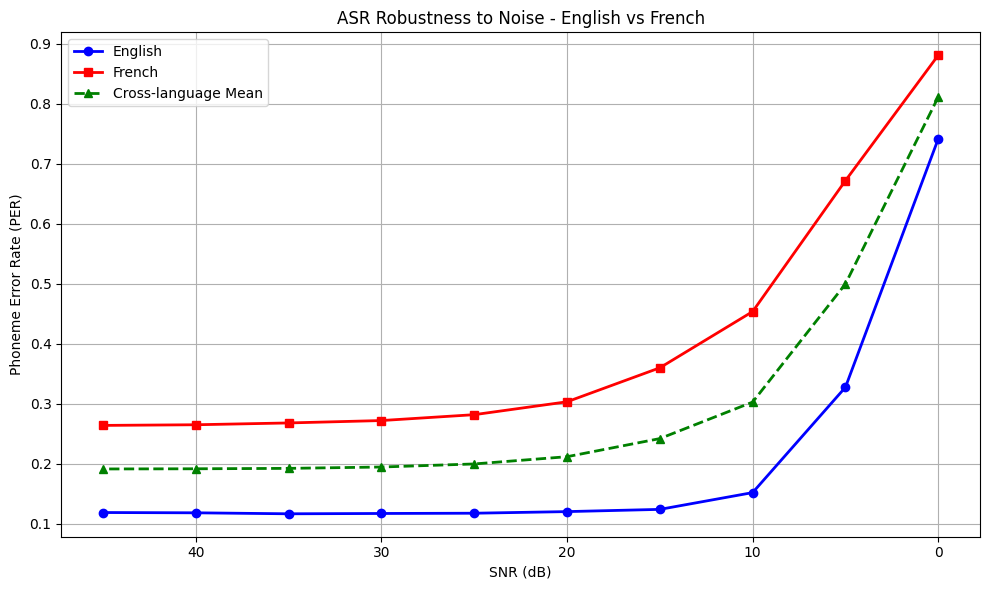

Figure saved!


In [29]:
# Calculate cross-language mean
mean_per = {snr: (results[snr] + results_fr[snr]) / 2 for snr in snr_levels}

# Plot
plt.figure(figsize=(10, 6))

plt.plot(snr_values, list(results.values()),
         marker='o', linewidth=2, color='blue', label='English')
plt.plot(snr_values, list(results_fr.values()),
         marker='s', linewidth=2, color='red', label='French')
plt.plot(snr_values, list(mean_per.values()),
         marker='^', linewidth=2, color='green', linestyle='--', label='Cross-language Mean')

plt.xlabel('SNR (dB)')
plt.ylabel('Phoneme Error Rate (PER)')
plt.title('ASR Robustness to Noise - English vs French')
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig("outputs/figures/per_vs_snr_all.png", dpi=150)
plt.show()

print("Figure saved!")

In [30]:
metrics = {
    "english": {
        f"snr_{snr}db": round(per, 4)
        for snr, per in results.items()
    },
    "french": {
        f"snr_{snr}db": round(per, 4)
        for snr, per in results_fr.items()
    },
    "mean": {
        f"snr_{snr}db": round(per, 4)
        for snr, per in mean_per.items()
    }
}

with open("outputs/metrics/per_results.json", 'w') as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved!")
print(json.dumps(metrics, indent=2))

Metrics saved!
{
  "english": {
    "snr_0db": 0.7418,
    "snr_5db": 0.3277,
    "snr_10db": 0.1521,
    "snr_15db": 0.1241,
    "snr_20db": 0.1204,
    "snr_25db": 0.1177,
    "snr_30db": 0.1173,
    "snr_35db": 0.1168,
    "snr_40db": 0.1184,
    "snr_45db": 0.1189
  },
  "french": {
    "snr_0db": 0.8811,
    "snr_5db": 0.6721,
    "snr_10db": 0.4539,
    "snr_15db": 0.3601,
    "snr_20db": 0.3035,
    "snr_25db": 0.282,
    "snr_30db": 0.2722,
    "snr_35db": 0.2682,
    "snr_40db": 0.2652,
    "snr_45db": 0.2641
  },
  "mean": {
    "snr_0db": 0.8114,
    "snr_5db": 0.4999,
    "snr_10db": 0.303,
    "snr_15db": 0.2421,
    "snr_20db": 0.2119,
    "snr_25db": 0.1999,
    "snr_30db": 0.1947,
    "snr_35db": 0.1925,
    "snr_40db": 0.1918,
    "snr_45db": 0.1915
  }
}


In [31]:
import shutil
shutil.make_archive("lab3_output", "zip", ".")
print("Zipped!")

Zipped!


In [32]:
from google.colab import files
files.download("lab3_output.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from google.colab import files
files.download("outputs/figures/per_vs_snr_all.png")
files.download("outputs/metrics/per_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>